In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
matplotlib.style.use('ggplot')
%matplotlib inline

In [3]:
town_1959_df = pd.read_csv('town_1959_2.csv', encoding = 'cp1251')

In [4]:
town_1959_df.set_index(u'номер')

,город,население
номер,,
1,Москва,5046.0
2,Санкт-Петербург,3003.0
3,Нижний_Новгород,941.0
4,Новосибирск,885.0
5,Самара,806.0
...,...,...
1 000,Усть-Илимск,0.5
1 001,Ясный,0.5
1 002,Мегион,0.4


In [13]:
town_1959_df.head()

,номер,город,население
0,1,Москва,5046.0
1,2,Санкт-Петербург,3003.0
2,3,Нижний_Новгород,941.0
3,4,Новосибирск,885.0
4,5,Самара,806.0


(array([  1.,   8.,  24., 127., 408., 302.,  88.,  33.,  11.,   2.]),
 array([-1.        , -0.52970528, -0.05941055,  0.41088417,  0.8811789 ,
         1.35147362,  1.82176835,  2.29206307,  2.7623578 ,  3.23265252,
         3.70294725]),
 <BarContainer object of 10 artists>)

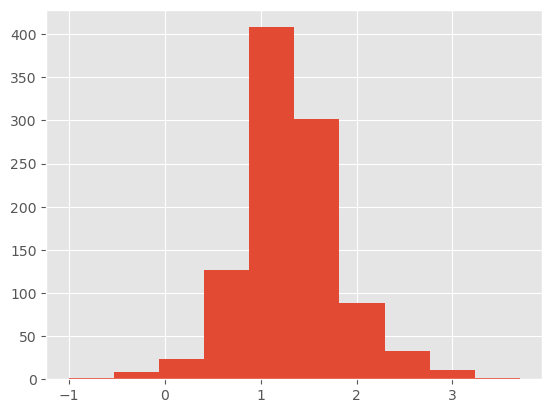

In [5]:
plt.hist(np.log10(town_1959_df[u'население']))

In [7]:
res = stats.shapiro(np.log10(town_1959_df[u'население']))

In [9]:
print('p-value:', res[1])

p-value: 3.1499992999375674e-12


(array([ 1.,  0.,  0.,  0.,  0.,  1.,  1.,  3.,  2.,  1.,  1.,  2.,  4.,
         7., 10.,  7., 19., 21., 32., 48., 49., 91., 86., 89., 93., 78.,
        78., 63., 42., 41., 21., 23., 16., 16., 12.,  8., 12.,  8.,  4.,
         1.,  7.,  3.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  1.]),
 array([-1.        , -0.90594106, -0.81188211, -0.71782317, -0.62376422,
        -0.52970528, -0.43564633, -0.34158739, -0.24752844, -0.1534695 ,
        -0.05941055,  0.03464839,  0.12870734,  0.22276628,  0.31682523,
         0.41088417,  0.50494312,  0.59900206,  0.69306101,  0.78711995,
         0.8811789 ,  0.97523784,  1.06929679,  1.16335573,  1.25741468,
         1.35147362,  1.44553257,  1.53959151,  1.63365046,  1.7277094 ,
         1.82176835,  1.91582729,  2.00988624,  2.10394518,  2.19800413,
         2.29206307,  2.38612202,  2.48018096,  2.57423991,  2.66829885,
         2.7623578 ,  2.85641674,  2.95047569,  3.04453463,  3.13859358,
         3.23265252,  3.32671147,  3.42077041,  3.51482936,

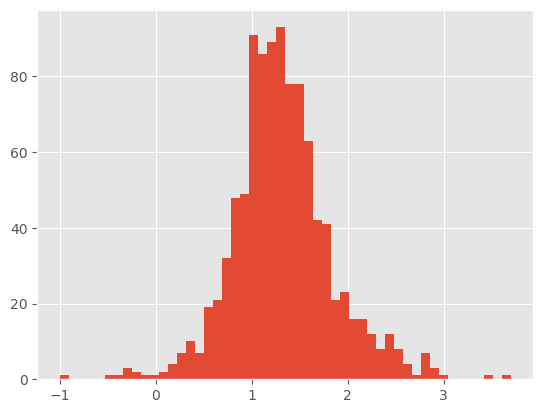

In [10]:
plt.hist(np.log10(town_1959_df[u'население']), bins = 50)

In [11]:
albuquerque_home_prices_df = pd.read_csv('Albuquerque Home Prices_data.txt', sep = '\t')

In [12]:
albuquerque_home_prices_df.head()

,PRICE,SQFT,AGE,FEATS,NE,CUST,COR,TAX
0,2050,2650,13,7,1,1,0,1639
1,2080,2600,-9999,4,1,1,0,1088
2,2150,2664,6,5,1,1,0,1193
3,2150,2921,3,6,1,1,0,1635
4,1999,2580,4,4,1,1,0,1732


In [15]:
albuquerque_home_prices_df = albuquerque_home_prices_df.replace(-9999, np.nan)

In [17]:
x = albuquerque_home_prices_df[albuquerque_home_prices_df['COR'] == 1]['PRICE']
y = albuquerque_home_prices_df[albuquerque_home_prices_df['COR'] == 0]['PRICE']
x.name, y.name = 'Corner', 'Not Corner'

In [22]:
def two_histograms(x, y):
    x.hist(alpha = 0.5, weights = [1. / len(x)] * len(x))
    y.hist(alpha = 0.5, weights = [1. / len(y)] * len(y))
    plt.axvline(x.mean(), color = 'red', alpha = 0.8, linestyle = 'dashed')
    plt.axvline(y.mean(), color = 'blue', alpha = 0.8, linestyle = 'dashed')
    plt.legend([x.name, y.name])

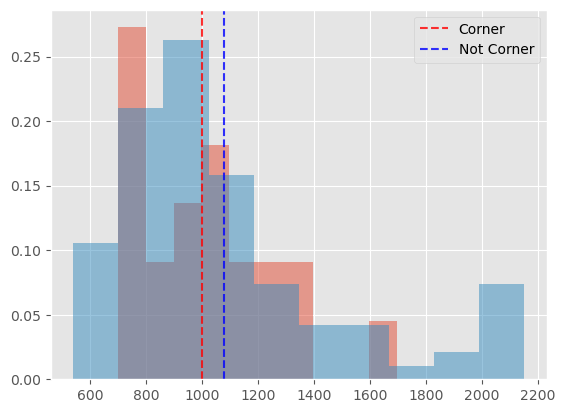

In [23]:
two_histograms(x, y)